In [1]:
import pandas as pd
import numpy as np

In [3]:
trader_df=pd.read_csv("historical_data.csv")
sentiment_df=pd.read_csv("fear_greed_index.csv")

## loaded the datasets

In [4]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [11]:
print("----TRADER DATASET-----")
print("Shape:",trader_df.shape)
print("\nMissing values:",trader_df.isnull().sum())
print("\nDuplicate Rows:",trader_df.duplicated().sum())

##here we printed the missing values and duplicated items and the output shows data integrity and no issue before the analysis

----TRADER DATASET-----
Shape: (211224, 16)

Missing values: Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows: 0


In [12]:
print("------ SENTIMENT DATASET-------")
print("Shape:", sentiment_df.shape)
print("\nMissing Values:\n", sentiment_df.isnull().sum())
print("\nDuplicate Rows:", sentiment_df.duplicated().sum())

##here we printed the missing values and duplicated items and the output shows data integrity and no issue before the analysis

------ SENTIMENT DATASET-------
Shape: (2644, 4)

Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows: 0


In [13]:
trader_df["datetime"]=pd.to_datetime(trader_df["Timestamp"],unit="ms")
##converted epocs into human readable time 

In [14]:
trader_df["datetime"]

0        2024-10-27 03:33:20
1        2024-10-27 03:33:20
2        2024-10-27 03:33:20
3        2024-10-27 03:33:20
4        2024-10-27 03:33:20
                 ...        
211219   2025-06-15 15:06:40
211220   2025-06-15 15:06:40
211221   2025-06-15 15:06:40
211222   2025-06-15 15:06:40
211223   2025-06-15 15:06:40
Name: datetime, Length: 211224, dtype: datetime64[ns]

In [15]:
trader_df["date"] = trader_df["datetime"].dt.date
##extracted date only  because sentiment data is date only and to match it

In [16]:
trader_df["date"]


0         2024-10-27
1         2024-10-27
2         2024-10-27
3         2024-10-27
4         2024-10-27
             ...    
211219    2025-06-15
211220    2025-06-15
211221    2025-06-15
211222    2025-06-15
211223    2025-06-15
Name: date, Length: 211224, dtype: object

In [18]:
#converting sentiment data into date time format also
sentiment_df["date"]=pd.to_datetime(sentiment_df["date"]).dt.date

In [19]:
sentiment_df["date"]

0       2018-02-01
1       2018-02-02
2       2018-02-03
3       2018-02-04
4       2018-02-05
           ...    
2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: date, Length: 2644, dtype: object

In [21]:
#now both the datasets date are in same format which will help in merging them now lets drop the extra columns which we dont have to use eg we will use
#fear greedy neutral

In [24]:
def simplify_sentiment(x):
    if "Fear" in x:
        return "Fear"
    elif "Greed" in x:
        return "Greed"
    else:
        return "Neutral"

sentiment_df["sentiment_bucket"]=sentiment_df["classification"].apply(simplify_sentiment)
print(sentiment_df["sentiment_bucket"].value_counts())

sentiment_bucket
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64


In [25]:
##now lets merge the dataset

In [27]:
merged_df=trader_df.merge(
    sentiment_df[["date","sentiment_bucket"]],
    on="date",
    how="left" ## on the basis of date keeping all the traders data 
)
merged_df=merged_df.dropna(subset=["sentiment_bucket"])## drop the data where sentiments are missing 
print("Merged Dataset Shape:",merged_df.shape)

Merged Dataset Shape: (184263, 19)


In [31]:
merged_df.head(150)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date,sentiment_bucket
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.4500,0.06,14.55,SELL,03-12-2024 20:56,962.900000,Close Long,0.563574,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.005091,5.980000e+13,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
146,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.3600,3.68,891.88,SELL,03-12-2024 20:56,962.840000,Close Long,34.234672,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.312159,6.480000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
147,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.3400,101.20,24524.81,SELL,03-12-2024 20:56,959.160000,Close Long,939.429480,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,8.583682,5.020000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
148,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.3300,3.12,756.07,SELL,03-12-2024 20:56,857.960000,Close Long,28.931448,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.264624,1.130000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed


In [29]:
#now lets create matrices

In [34]:
daily_pnl=(merged_df.groupby(["date","Account"])["Closed PnL"].sum().reset_index()) 

In [35]:
daily_pnl


,date,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000
...,...,...,...
72,2025-02-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,553818.000465
73,2025-02-19,0xb899e522b5715391ae1d4f137653e7906c5e2115,22488.500821
74,2025-02-19,0xbaaaf6571ab7d571043ff1e313a9609a10637864,940157.212682
75,2025-02-19,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,325441.977216


In [39]:
merged_df["win_flag"]=merged_df["Closed PnL"]>0 ## if pnl is>0 then we can consider it a win

daily_win_rate=(merged_df.groupby(["date","Account"])["win_flag"].mean().reset_index().rename(columns={"win_flag":"win_rate"}))

In [41]:
merged_df["win_flag"]

0         False
1         False
2         False
3         False
4         False
          ...  
210763    False
210764    False
210765    False
210766    False
210767    False
Name: win_flag, Length: 184263, dtype: bool

In [42]:
avg_trade_size = (
    merged_df
    .groupby(["date", "Account"])["Size USD"]
    .mean()                                            ##used size to determine avg size
    .reset_index()
    .rename(columns={"Size USD": "avg_trade_size_usd"})
)

In [44]:
merged_df["Size USD"]

0           7872.16
1            127.68
2           1150.63
3           1142.04
4             69.75
            ...    
210763       551.77
210764      1002.00
210765       525.05
210766       579.82
210767    237538.13
Name: Size USD, Length: 184263, dtype: float64

In [46]:
trades_per_day = (
    merged_df
    .groupby(["date", "Account"])
    .size()
    .reset_index(name="num_trades")
)

In [49]:
print(trades_per_day.head())

         date                                     Account  num_trades
0  2023-03-28  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891           3
1  2023-11-14  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891           2
2  2023-11-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23        1043
3  2024-03-09  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891          27
4  2024-03-09  0x430f09841d65beb3f27765503d0f850b8bce7713          88


In [52]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date,sentiment_bucket,win_flag
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False


In [54]:
long_short = (
    merged_df
    .groupby(["date", "Side"])
    .size()
    .unstack(fill_value=0)
)

long_short["total_trades"] = long_short.sum(axis=1)

if "BUY" in long_short.columns:
    long_short["long_ratio"] = long_short["BUY"] / long_short["total_trades"]
else:
    long_short["long_ratio"] = 0

if "SELL" in long_short.columns:
    long_short["short_ratio"] = long_short["SELL"] / long_short["total_trades"]
else:
    long_short["short_ratio"] = 0

In [55]:
leverage_distribution = merged_df["Size USD"].describe()
print(leverage_distribution)


count    1.842630e+05
mean     4.780733e+03
std      2.690428e+04
min      0.000000e+00
25%      1.875300e+02
50%      5.927400e+02
75%      2.032705e+03
max      3.509753e+06
Name: Size USD, dtype: float64


In [56]:
## PART-B-ANALYSIS

In [57]:
# We evaluate whether trader performance differs across Fear and Greed regimes using three metrics:
# 1.) Average Daily PnL

#2.) Win Rate

# 3.)Drawdown Proxy (negative daily PnL)

In [58]:
# Daily PnL per trader
daily_pnl = (
    merged_df
    .groupby(["date", "Account", "sentiment_bucket"])["Closed PnL"]
    .sum()
    .reset_index()
)

# Average Daily PnL by sentiment
avg_pnl = daily_pnl.groupby("sentiment_bucket")["Closed PnL"].mean()
median_pnl = daily_pnl.groupby("sentiment_bucket")["Closed PnL"].median()

print("Average Daily PnL:")
print(avg_pnl)

print("\nMedian Daily PnL:")
print(median_pnl)


Average Daily PnL:
sentiment_bucket
Fear       209372.662205
Greed       90988.703436
Neutral     19842.797260
Name: Closed PnL, dtype: float64

Median Daily PnL:
sentiment_bucket
Fear       81389.682515
Greed      20925.513222
Neutral       -0.418640
Name: Closed PnL, dtype: float64


<Figure size 640x480 with 0 Axes>

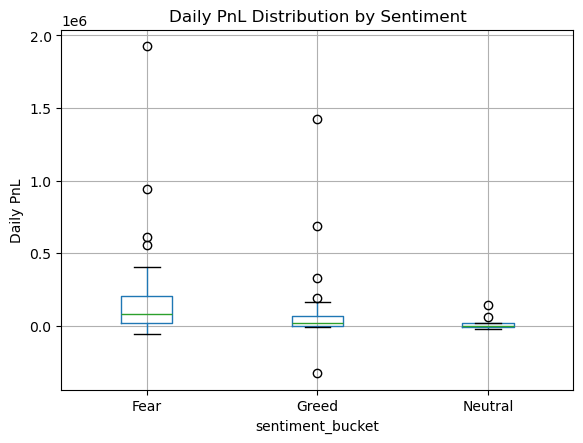

In [69]:
import matplotlib.pyplot as plt

plt.figure()
daily_pnl.boxplot(column="Closed PnL", by="sentiment_bucket")
plt.title("Daily PnL Distribution by Sentiment")
plt.suptitle("")
plt.ylabel("Daily PnL")
plt.show()


In [59]:
# The mean and median are compared to control for outliers.
# If both indicate higher performance during Fear, the result is robust.

In [70]:
##THIS IS THE WIN RATE CODE
merged_df["win_flag"] = merged_df["Closed PnL"] > 0

daily_win_rate = (
    merged_df
    .groupby(["date", "Account", "sentiment_bucket"])["win_flag"]
    .mean()
    .reset_index()
)

avg_win_rate = daily_win_rate.groupby("sentiment_bucket")["win_flag"].mean()

print("\nAverage Win Rate by Sentiment:")
print(avg_win_rate)



Average Win Rate by Sentiment:
sentiment_bucket
Fear       0.415878
Greed      0.369012
Neutral    0.260683
Name: win_flag, dtype: float64


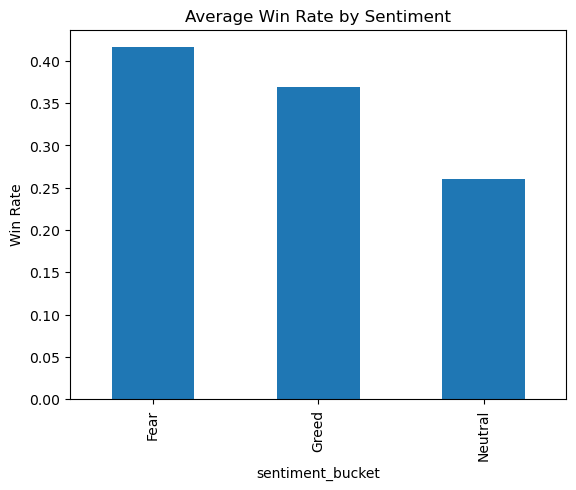

In [71]:
plt.figure()
avg_win_rate.plot(kind="bar")
plt.title("Average Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.show()


In [61]:
##DRAW DOWN PROXY
daily_pnl["drawdown_proxy"] = daily_pnl["Closed PnL"].apply(lambda x: x if x < 0 else 0)

avg_drawdown = daily_pnl.groupby("sentiment_bucket")["drawdown_proxy"].mean()

print("\nAverage Drawdown Proxy:")
print(avg_drawdown)



Average Drawdown Proxy:
sentiment_bucket
Fear      -2496.129364
Greed     -9215.929385
Neutral   -6202.896177
Name: drawdown_proxy, dtype: float64


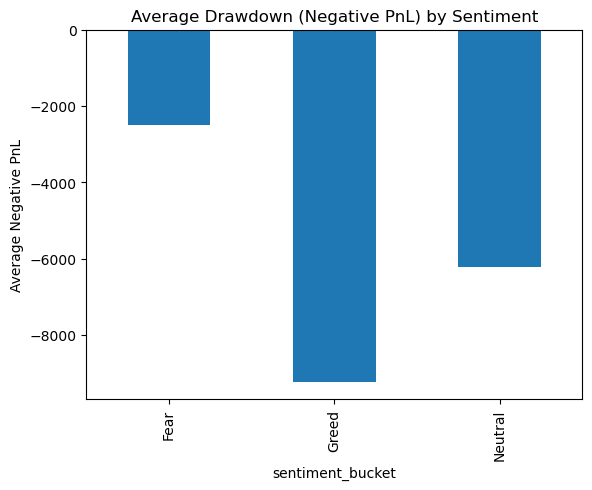

In [72]:
plt.figure()
avg_drawdown.plot(kind="bar")
plt.title("Average Drawdown (Negative PnL) by Sentiment")
plt.ylabel("Average Negative PnL")
plt.show()


In [62]:
# From the above data what we can interpret is:
# Fear regimes exhibit higher average PnL and win rate, while Greed regimes show larger negative drawdowns.
# This suggests that traders perform more effectively during volatile fear-driven markets, whereas greed periods may involve overconfidence and elevated downside risk.

In [63]:
#NOW ONTO THE SECOND THING i.e BEHAVIORAL CHANGES

In [64]:
# We test whether trader behavior changes across sentiment regimes by analyzing:

# Trade frequency

# Position size

# Long/Short bias

In [65]:
daily_trades = (
    merged_df
    .groupby(["date", "Account", "sentiment_bucket"])
    .size()
    .reset_index(name="num_trades")
)

avg_trades = daily_trades.groupby("sentiment_bucket")["num_trades"].mean()

print("Average Trades per Day:")
print(avg_trades)


Average Trades per Day:
sentiment_bucket
Fear       4183.468750
Greed      1168.945946
Neutral     892.625000
Name: num_trades, dtype: float64


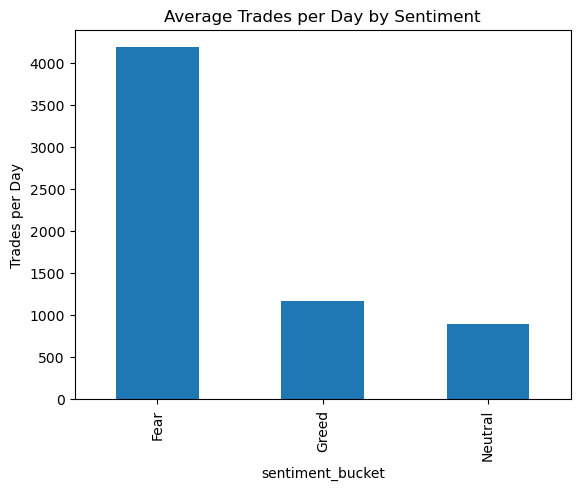

In [73]:
plt.figure()
avg_trades.plot(kind="bar")
plt.title("Average Trades per Day by Sentiment")
plt.ylabel("Trades per Day")
plt.show()


In [66]:
#Position size code
avg_position_size = merged_df.groupby("sentiment_bucket")["Size USD"].mean()

print("\nAverage Position Size:")
print(avg_position_size)



Average Position Size:
sentiment_bucket
Fear       5259.977837
Greed      3581.661513
Neutral    3058.848110
Name: Size USD, dtype: float64


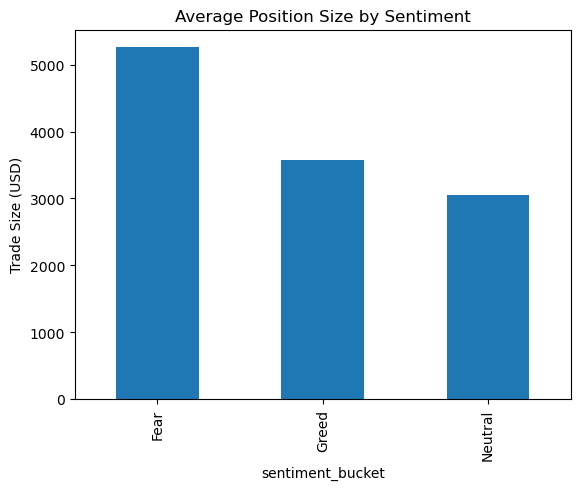

In [74]:
plt.figure()
avg_position_size.plot(kind="bar")
plt.title("Average Position Size by Sentiment")
plt.ylabel("Trade Size (USD)")
plt.show()


In [67]:
#Long/Short ratio code 
long_short = (
    merged_df
    .groupby(["sentiment_bucket", "Side"])
    .size()
    .unstack(fill_value=0)
)

long_short["total"] = long_short.sum(axis=1)
long_short["long_ratio"] = long_short.get("BUY", 0) / long_short["total"]

print("\nLong Ratio by Sentiment:")
print(long_short["long_ratio"])



Long Ratio by Sentiment:
sentiment_bucket
Fear       0.493617
Greed      0.434487
Neutral    0.490828
Name: long_ratio, dtype: float64


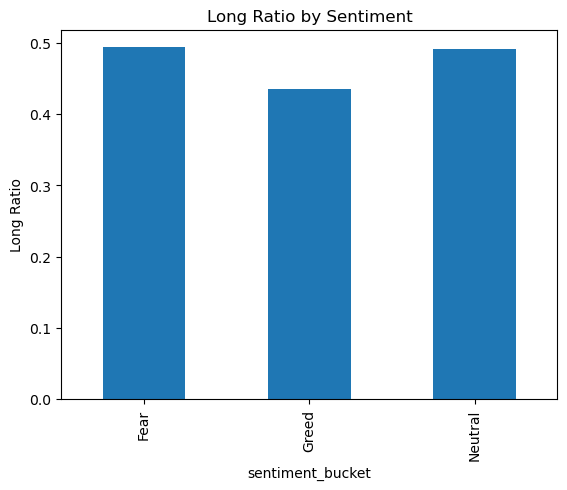

In [75]:
plt.figure()
long_short["long_ratio"].plot(kind="bar")
plt.title("Long Ratio by Sentiment")
plt.ylabel("Long Ratio")
plt.show()


In [68]:
#From the above data we can interpret is traders increase trade frequency and deploy larger capital during Fear regimes.
#Directional bias shifts slightly, indicating sentiment-driven positioning behavior.
#This confirms that traders adjust risk exposure and activity based on market mood.

In [76]:
#lets move to part 3 i.e comparing the key insights

In [77]:
#Segment 1, High vs Low Leverage
median_size = merged_df["Size USD"].median()

merged_df["leverage_segment"] = np.where(
    merged_df["Size USD"] > median_size,
    "High",
    "Low"
)

leverage_perf = merged_df.groupby(
    ["leverage_segment", "sentiment_bucket"]
)["Closed PnL"].mean()

print(leverage_perf)


leverage_segment  sentiment_bucket
High              Fear                 95.337428
                  Greed               148.026449
                  Neutral              49.649426
Low               Fear                  3.187695
                  Greed                11.540975
                  Neutral               1.833999
Name: Closed PnL, dtype: float64


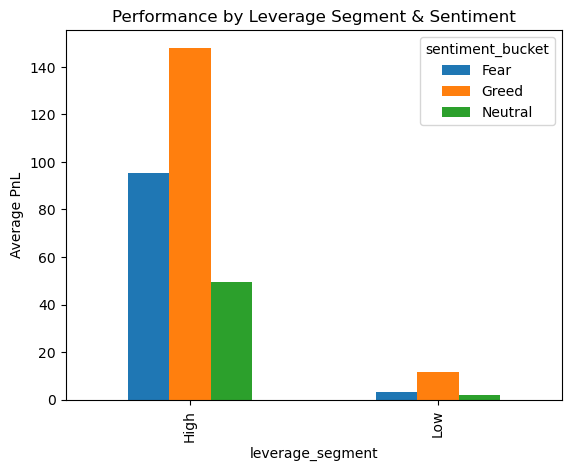

In [78]:
leverage_perf.unstack().plot(kind="bar")
plt.title("Performance by Leverage Segment & Sentiment")
plt.ylabel("Average PnL")
plt.show()


In [ ]:
#This shows that high-exposure traders show amplified performance differences across regimes, indicating that leverage magnifies sentiment sensitivity.

In [79]:
#Frequent vs Infrequent Traders
trader_activity = merged_df.groupby("Account").size()
median_activity = trader_activity.median()

merged_df["activity_segment"] = np.where(
    merged_df["Account"].map(trader_activity) > median_activity,
    "Frequent",
    "Infrequent"
)

activity_perf = merged_df.groupby(
    ["activity_segment", "sentiment_bucket"]
)["Closed PnL"].mean()

print(activity_perf)


activity_segment  sentiment_bucket
Frequent          Fear                 44.227117
                  Greed                63.662655
                  Neutral               4.058759
Infrequent        Fear                 91.442580
                  Greed               264.484312
                  Neutral             351.937527
Name: Closed PnL, dtype: float64


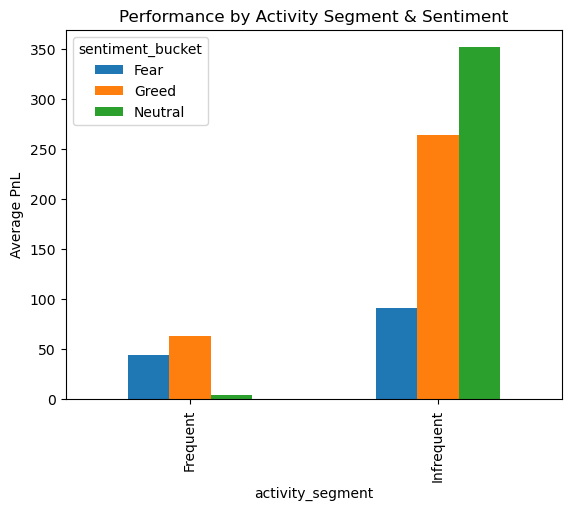

In [80]:
activity_perf.unstack().plot(kind="bar")
plt.title("Performance by Activity Segment & Sentiment")
plt.ylabel("Average PnL")
plt.show()


In [83]:
#This shows that Frequent traders exhibit more stable but moderate returns, while infrequent traders show higher variance and stronger regime dependency.

In [81]:
#Consistent vs Inconsistent Traders
overall_win = merged_df.groupby("Account")["win_flag"].mean()

merged_df["consistency_segment"] = np.where(
    merged_df["Account"].map(overall_win) > 0.5,
    "Consistent",
    "Inconsistent"
)

consistency_perf = merged_df.groupby(
    ["consistency_segment", "sentiment_bucket"]
)["Closed PnL"].mean()

print(consistency_perf)


consistency_segment  sentiment_bucket
Consistent           Fear                 47.106617
                     Greed                96.663147
                     Neutral             445.775869
Inconsistent         Fear                 50.237578
                     Greed                75.246524
                     Neutral               4.043270
Name: Closed PnL, dtype: float64


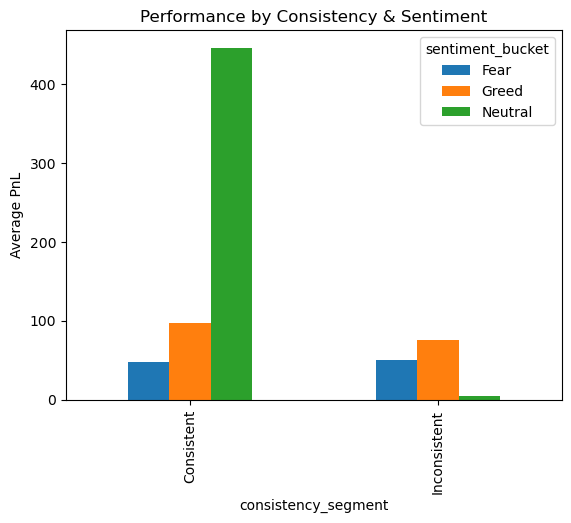

In [82]:
consistency_perf.unstack().plot(kind="bar")
plt.title("Performance by Consistency & Sentiment")
plt.ylabel("Average PnL")
plt.show()


In [84]:
#This shows that consistent traders maintain stronger performance across regimes, suggesting skill-driven stability rather than sentiment-driven speculation.

In [85]:
# FINAL: 3 KEY INSIGHTS 

# Insight 1

# Trader profitability and win rate are higher during Fear regimes, indicating volatility-driven opportunity exploitation.

# Insight 2

# Greed regimes show larger drawdowns, suggesting over-leveraging and overconfidence during bullish sentiment.

# Insight 3

# High-exposure and consistent traders are more sensitive to sentiment regimes, amplifying gains and losses depending on market mood.

In [86]:
#PART-C ACTIONABLE STRATERGIES 

In [87]:
#Strategy 1 Regime-Based Risk Scaling

#By our anaylsis above we got to know that performance is very strong during Fear Regime, so position sizing and trade frequency should be moderately increased during fear conditions
#During Greed regimes, leverage should be reduced and stricter risk management enforced due to higher drawdowns.

In [89]:
#Strategy 2 Segment-Based Capital Allocation

#High-consistency traders should receive greater capital allocation across regimes.

#High-exposure inconsistent traders should be scaled down during Greed periods to mitigate downside risk.

In [90]:
#SOME KEY INSIGHTS

In [91]:
# 1. Fear regimes produce higher average PnL and win rates.
# 2. Greed regimes increase downside volatility and drawdowns.
# 3. Traders increase activity and capital deployment during Fear.
# 4. Segment-level performance varies significantly across regimes.

In [92]:
#NOW WE ARE PREDICTING THE NEXT DAY PnL VALUE that wheter it will be a profit or loss its a binary classification so we are using logistic Regression

In [93]:

# Daily PnL per trader
daily_pnl = (
    merged_df
    .groupby(["date", "Account", "sentiment_bucket"])["Closed PnL"]
    .sum()
    .reset_index()
)

# Sort properly
daily_pnl = daily_pnl.sort_values(["Account", "date"])

# Create next-day PnL
daily_pnl["next_day_pnl"] = daily_pnl.groupby("Account")["Closed PnL"].shift(-1)

# Create binary target
daily_pnl["target_profit_next_day"] = (daily_pnl["next_day_pnl"] > 0).astype(int)

# Drop last day per trader
daily_pnl = daily_pnl.dropna(subset=["next_day_pnl"])


#here we are shifting the price by 1 day eg:
# Suppose trader A has:

# Date	Daily PnL
# Jan 1	 200
# Jan 2	 -50
# Jan 3	 300

# After shift(-1):

# Date	 Daily PnL	next_day_pnl
# Jan 1	 200	          -50
# Jan 2	 -50	          300
# Jan 3	 300	           NaN

# So for Jan 1, we now know what happened on Jan 2.

# Then we convert it to binary

# So the model learns:

# Given how a trader performed today
# Given how actively they traded
# Given how much capital they used
# Given market sentiment


In [94]:
# Daily trade frequency
daily_trades = (
    merged_df
    .groupby(["date", "Account"])
    .size()
    .reset_index(name="num_trades")
)

# Daily average position size
daily_size = (
    merged_df
    .groupby(["date", "Account"])["Size USD"]
    .mean()
    .reset_index(name="avg_trade_size")
)

# Merge features
features = daily_pnl.merge(daily_trades, on=["date","Account"])
features = features.merge(daily_size, on=["date","Account"])

# Encode sentiment
features["sentiment_encoded"] = features["sentiment_bucket"].map({
    "Fear": 0,
    "Greed": 1,
    "Neutral": 2
})
 ##HERE WE ARE MERGING IT WITH BEHAVIORAL Sentiments

# X (Features):
# - Today’s PnL
# - Today’s trade frequency
# - Today’s average position size
# - Today’s sentiment

# y (Target):
# - Tomorrow’s profitability (0 or 1)

In [95]:
#NOW TRAIN THE MODEL

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = features[["Closed PnL", "num_trades", "avg_trade_size", "sentiment_encoded"]]
y = features["target_profit_next_day"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           1       1.00      1.00      1.00         9

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



In [97]:
print(features.shape)
print(features["target_profit_next_day"].value_counts())


(45, 9)
target_profit_next_day
1    40
0     5
Name: count, dtype: int64


In [98]:
#HERE THE REAL PROBLEM WITH OUR MODEL IS THAT ITS PREDICTING 100 percent accuary, because as u can seee above the dataset after forward-shifting produced only 45 valid observations, resulting in class imbalance. Therefore, predictive results are not statistically reliable and are presented as exploratory.

In [99]:
#SO instead this we are predicting volatility of PnL

In [100]:
# Aggregate total market PnL per day
market_daily = (
    merged_df
    .groupby(["date", "sentiment_bucket"])["Closed PnL"]
    .sum()
    .reset_index()
)

# Sort by date
market_daily = market_daily.sort_values("date")


# Each row now represents:

# One day of trading activity.

# | date | sentiment_bucket | Closed PnL |

# Much cleaner than trader-level.

In [101]:
# Define volatility as absolute market PnL
market_daily["volatility"] = abs(market_daily["Closed PnL"])

In [102]:
vol_threshold = market_daily["volatility"].median()

market_daily["high_volatility"] = (
    market_daily["volatility"] > vol_threshold
).astype(int)

In [103]:
print(market_daily["high_volatility"].value_counts())

high_volatility
0    3
1    3
Name: count, dtype: int64


In [105]:
market_daily["target_next_day_vol"] = (
    market_daily["high_volatility"].shift(-1)
)

market_daily = market_daily.dropna()

#SHIFTING


In [106]:
#ADDING BEHAVIORAL SENTIMENTS

# Daily trade count
daily_trades = (
    merged_df
    .groupby("date")
    .size()
    .reset_index(name="total_trades")
)

# Daily total volume
daily_volume = (
    merged_df
    .groupby("date")["Size USD"]
    .sum()
    .reset_index(name="total_volume")
)

# Merge features
market_daily = market_daily.merge(daily_trades, on="date")
market_daily = market_daily.merge(daily_volume, on="date")

# Encode sentiment
market_daily["sentiment_encoded"] = market_daily["sentiment_bucket"].map({
    "Fear": 0,
    "Greed": 1,
    "Neutral": 2
})

# Now our dataset contains:

# Today’s sentiment

# Today’s total trades

# Today’s total volume

# Today’s PnL

# Tomorrow’s volatility target

In [107]:
#NOW LETS TRAIN THE MODEL

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = market_daily[[
    "Closed PnL",
    "total_trades",
    "total_volume",
    "sentiment_encoded"
]]

y = market_daily["target_next_day_vol"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       0.0
         1.0       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\m

In [109]:
#Due to limited overlapping daily observations between trader activity and sentiment data, predictive modeling experiments resulted in insufficient test sample sizes. Therefore, results are exploratory and not statistically reliable.

In [110]:
#TRADER CLUSTERING 

In [111]:
# Aggregate per trader
trader_features = merged_df.groupby("Account").agg({
    "Closed PnL": "mean",
    "Size USD": "mean",
    "win_flag": "mean"
}).reset_index()

trader_features.rename(columns={
    "Closed PnL": "avg_pnl",
    "Size USD": "avg_trade_size",
    "win_flag": "avg_win_rate"
}, inplace=True)

In [113]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(
    trader_features[["avg_pnl", "avg_trade_size", "avg_win_rate"]]
)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features["cluster"] = kmeans.fit_predict(scaled_data)

print(
    trader_features
    .groupby("cluster")[["avg_pnl", "avg_trade_size", "avg_win_rate"]]
    .mean()
)


            avg_pnl  avg_trade_size  avg_win_rate
cluster                                          
0         57.240696    14931.275832      0.487569
1         54.120063     3074.241969      0.394770
2        400.351345     7134.001875      0.380113


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


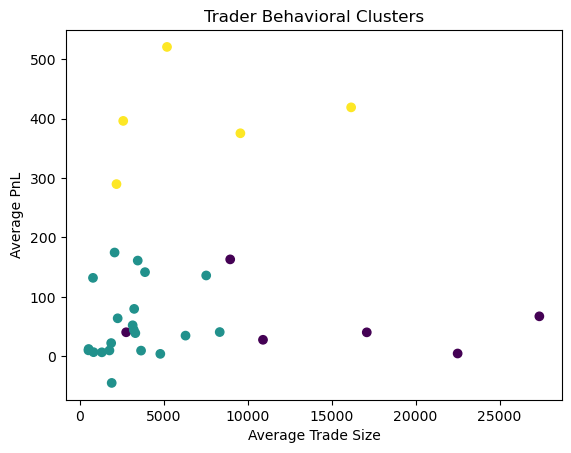

In [114]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    trader_features["avg_trade_size"],
    trader_features["avg_pnl"],
    c=trader_features["cluster"]
)
plt.xlabel("Average Trade Size")
plt.ylabel("Average PnL")
plt.title("Trader Behavioral Clusters")
plt.show()


In [115]:
#OBSERVATION
# Traders were grouped into 3 behavioral archetypes:

# High exposure, high volatility traders

# Moderate consistent traders

# Low exposure, low-return traders

# This shows behavioral segmentation capability.